# Evaluation of BERT Task Classifier

In this notebook, we will evalate the BERT multi-label classifier. Firstly, we will evaluate it based on the saved results for the train-val-test sets with the 2023-24-25 data. Secondly, we will evaluate it on the inference set - 14 manually annotated teams from 2022.

As an LLM was also used to do the same classifying task, it is evaluated in this notebook by comparing to the gold standard of 14 teams. In this way, the performance of the BERT and the LLM can be compared.

In [1]:
import ast
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, multilabel_confusion_matrix, f1_score
from matplotlib import cm
import os

In [2]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (8, 6),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

In [31]:
BERT_OUTPUTS_PATH = "../data/attributions/2022_attributions/bert/bert_inference_outputs/14_teams_bert_classified_tasks.tsv"
GOLD_STANDARD_PATH = "../data/attributions/2022_attributions/manual_annotation/14_random_teams_tasks.tsv"
TRAINING_RESULTS_DIR = "../data/attributions/2022_attributions/bert/bert_training_data/model_results/"
LLM_OUTPUTS_PATH = "../data/attributions/2022_attributions/llm_classification_outputs/14_teams_llm_classified_tasks.tsv"

LOSS_FILE = os.path.join(TRAINING_RESULTS_DIR, "loss_history.csv")
OVERALL_FILE = os.path.join(TRAINING_RESULTS_DIR, "overall_metrics.csv")
TEST_LABELS_FILE = os.path.join(TRAINING_RESULTS_DIR, "test_per_label_metrics.csv")

TASK_LABELS = [
    "software","conceptualization","public engagement","writing","investigation",
    "hardware","project administration","entrepreneurship","fundraising",
    "background research","safety","analysis","visualization","data curation",
] # without "lab maintenance"

LABEL2ID = {label: i for i, label in enumerate(TASK_LABELS)} #give task names ids

## 1. BERT Training Results

In [32]:
# Loss and Metrics Files
df_loss = pd.read_csv(LOSS_FILE)
df_overall = pd.read_csv(OVERALL_FILE)
df_test_labels = pd.read_csv(TEST_LABELS_FILE)

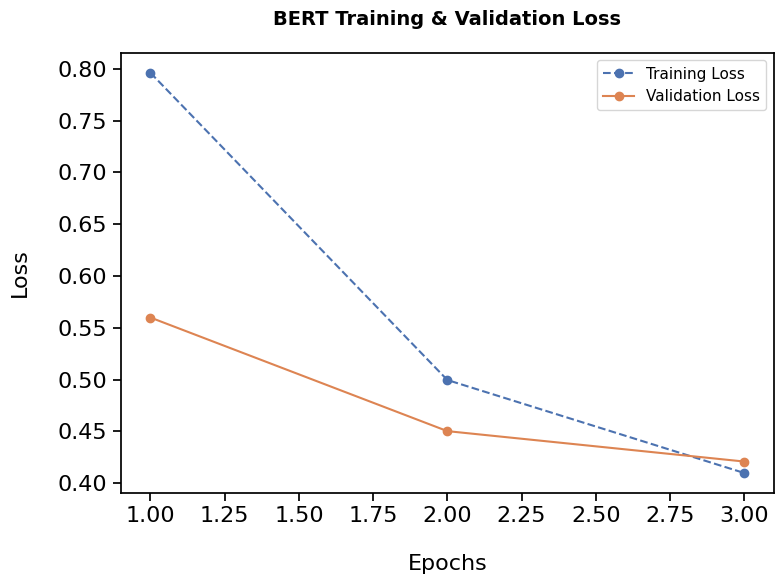

In [33]:
# Plot loss curves
plt.plot(df_loss['epoch'], df_loss['train_loss'], label='Training Loss', marker='o', linestyle='--')
plt.plot(df_loss['epoch'], df_loss['val_loss'], label='Validation Loss', marker='o')
plt.title('BERT Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

In [34]:
# Overall Evaluation Summary
print("\n" + "="*50)
print("             BERT EVALUATION SUMMARY")
print("="*50)
print(df_overall[['split', 'macro_f1', 'micro_f1']].to_string(index=False))
print("-" * 50)


             BERT EVALUATION SUMMARY
split  macro_f1  micro_f1
train  0.847373  0.836169
  val  0.821961  0.818569
 test  0.805645  0.816548
--------------------------------------------------


Loss curves for 3 epochs are shown in the previous graph. Both the training and validation loss are approaching zero with the 3 epochs, meaning that the model is not overfitting on the train set.  The overall F1 scores are around 0.85 across all three datasets (train, val, test), not showing underfitting or overfitting.

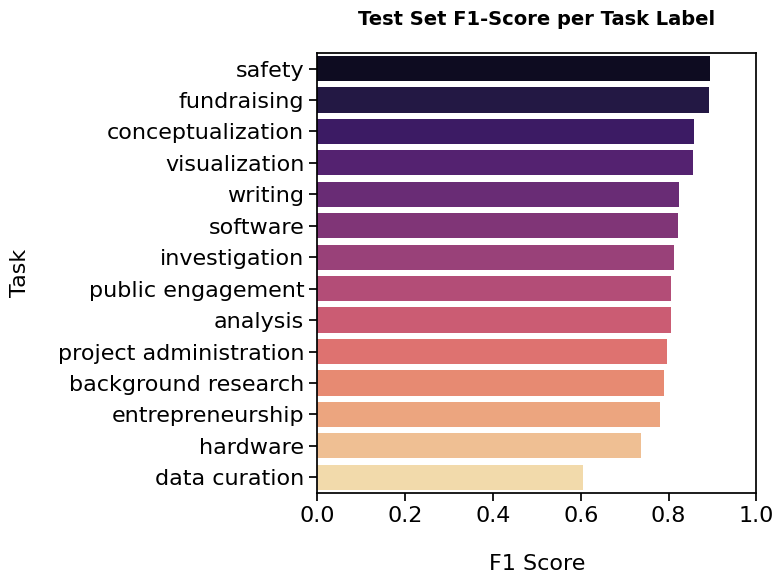

In [35]:
# Classification Report per Label
df_test_labels = df_test_labels.sort_values('f1', ascending=False)

sns.barplot(data=df_test_labels, x='f1', y='label', palette='magma', hue='label')
plt.title('Test Set F1-Score per Task Label', fontsize=14)
plt.xlabel('F1 Score')
plt.ylabel('Task')
plt.xlim(0, 1.0)
plt.tight_layout()

## 2. Bert Inference Evaluation

In [36]:
gold_df = pd.read_csv(GOLD_STANDARD_PATH, sep="\t")
bert_df = pd.read_csv(BERT_OUTPUTS_PATH, sep="\t")

In [37]:
gold_df.head()

,RawTextName,RosterName,Team,TasksDescription,CommentsLLM,Tasks,CommentsBERT
0,Melissa Hendrén,Melissa Hendr�n,Aalto-Helsinki,She is head of the wet-lab team and involved i...,The team does not include a name subtitle for ...,"[""investigation"", ""project administration"", ""f...",NaN
1,Veera Kurki,Veera Kurki,Aalto-Helsinki,"She is head of the human practices, the social...","Didn't include ""is one of the team co-leads to...","[""investigation"", ""project administration"", ""f...",NaN
2,Diogo Dias,Diogo Dias,Aalto-Helsinki,is head of the dry-lab. He is involved in the ...,"Didn't include ""is one of the team co-leads to...","[""analysis"",""writing"", ""visualization"",""projec...",NaN
3,Amna Gul,Amna Gul,Aalto-Helsinki,is an active member of the wet-lab team. She c...,NaN,"[""investigation"",""fundraising"",""public engagem...",NaN
4,Lilith Heiland,Lilith Heiland,Aalto-Helsinki,is head of the writing team and part of the we...,NaN,"[""writing"",""project administration"",""investiga...",NaN


In [38]:
bert_df.head()

,Team,FullName,TasksDescription,Tasks
0,Aalto-Helsinki,Melissa Hendr�n,She is head of the wet-lab team and involved i...,['fundraising']
1,Aalto-Helsinki,Veera Kurki,"She is head of the human practices, the social...","['public engagement', 'fundraising']"
2,Aalto-Helsinki,Diogo Dias,is head of the dry-lab. He is involved in the ...,['analysis']
3,Aalto-Helsinki,Amna Gul,is an active member of the wet-lab team. She c...,"['public engagement', 'fundraising']"
4,Aalto-Helsinki,Lilith Heiland,is head of the writing team and part of the we...,"['public engagement', 'fundraising']"


In [39]:
# Convert Tasks column from string representation of list to actual list

def convert_to_list(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or val is None:
        return [] # Turn nulls into empty list
    if isinstance(val, str):
        # Turn "[a, b]" into [a, b] 
        return ast.literal_eval(val)
    return val

In [40]:
gold_df["Tasks"] = gold_df["Tasks"].apply(convert_to_list)
bert_df["Tasks"] = bert_df["Tasks"].apply(convert_to_list)

In [41]:
# Remove "lab maintenance" from the gold standard tasks - BERT wasn't trained on that task label

gold_df["Tasks"] = gold_df["Tasks"].apply(
    lambda x: [task for task in x if task != "lab maintenance"] if isinstance(x, list) else x
)

In [42]:
# Check unique tasks in gold standard - to see if all are correct 
unique_tasks = sorted({
    t for row in gold_df["Tasks"] 
    if isinstance(row, list) 
    for t in row
})

unique_tasks

['analysis',
 'background research',
 'conceptualization',
 'data curation',
 'entrepreneurship',
 'fundraising',
 'hardware',
 'investigation',
 'project administration',
 'public engagement',
 'safety',
 'software',
 'visualization',
 'writing']

In [43]:
def tasks_to_multihot(tasks):
    vec = [0] * len(TASK_LABELS)  # initialize zero vector
    
    # For lis of tasks, set corresponding indices to 1
    if isinstance(tasks, list):
        for t in tasks:
            if t in LABEL2ID:
                vec[LABEL2ID[t]] = 1
        return vec
    
    # If it's not a list, check for null/None values
    if pd.isna(tasks) or tasks is None:
        return vec

In [44]:
gold_df["Labels"] = gold_df["Tasks"].apply(tasks_to_multihot)
bert_df["Labels"] = bert_df["Tasks"].apply(tasks_to_multihot)

# Rename and reorder columns
gold_df = gold_df.rename(columns={"RosterName":"FullName"})
gold_df = gold_df[["Team", "FullName", "TasksDescription", "Tasks", "Labels"]]

In [45]:
gold_df

,Team,FullName,TasksDescription,Tasks,Labels
0,Aalto-Helsinki,Melissa Hendr�n,She is head of the wet-lab team and involved i...,"[investigation, project administration, fundra...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]"
1,Aalto-Helsinki,Veera Kurki,"She is head of the human practices, the social...","[investigation, project administration, fundra...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]"
2,Aalto-Helsinki,Diogo Dias,is head of the dry-lab. He is involved in the ...,"[analysis, writing, visualization, project adm...","[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0]"
3,Aalto-Helsinki,Amna Gul,is an active member of the wet-lab team. She c...,"[investigation, fundraising, public engagement...","[0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]"
4,Aalto-Helsinki,Lilith Heiland,is head of the writing team and part of the we...,"[writing, project administration, investigatio...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0]"
...,...,...,...,...,...
236,Aboa,Minttu Turunen,All team members participated in the general a...,"[conceptualization, writing, visualization, pu...","[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
237,Aboa,Nelli Heiskanen,All team members participated in the general a...,"[conceptualization, writing, fundraising, proj...","[0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]"
238,Aboa,Otto Rydman,All team members participated in the general a...,"[conceptualization, writing, investigation, pu...","[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]"
239,Aboa,Sini Kylä-Kaila,All team members participated in the general a...,"[conceptualization, writing, project administr...","[0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]"


In [46]:
bert_df.head()

,Team,FullName,TasksDescription,Tasks,Labels
0,Aalto-Helsinki,Melissa Hendr�n,She is head of the wet-lab team and involved i...,[fundraising],"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
1,Aalto-Helsinki,Veera Kurki,"She is head of the human practices, the social...","[public engagement, fundraising]","[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
2,Aalto-Helsinki,Diogo Dias,is head of the dry-lab. He is involved in the ...,[analysis],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]"
3,Aalto-Helsinki,Amna Gul,is an active member of the wet-lab team. She c...,"[public engagement, fundraising]","[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
4,Aalto-Helsinki,Lilith Heiland,is head of the writing team and part of the we...,"[public engagement, fundraising]","[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"


In [47]:
# Merge gold and bert dataframes on Team and FullName (because row order may not be the same)
# Inner join - only keep rows present in both dataframes

merged_gold_bert = gold_df.merge(
    bert_df,
    on=["Team", "FullName"],
    suffixes=("_gold", "_bert"),
    how="inner"
)

In [48]:
# True and Predicted labels as numpy arrays

y_true = np.array(merged_gold_bert["Labels_gold"].tolist())
y_pred = np.array(merged_gold_bert["Labels_bert"].tolist())

# Verification that the shape is (num of members, 14 labels)
print(f"Shape of True: {y_true.shape}")
print(f"Shape of Pred: {y_pred.shape}")

Shape of True: (241, 14)
Shape of Pred: (241, 14)


In [49]:
# Classification Report

report = classification_report(
    y_true, 
    y_pred, 
    target_names=TASK_LABELS, # target_names allows the report to show real task names instead of indices
    zero_division=0
)

print(" ----------------- BERT CLASSIFICATION REPORT ----------------- ")
print(report)

 ----------------- BERT CLASSIFICATION REPORT ----------------- 
                        precision    recall  f1-score   support

              software       0.62      0.65      0.64        23
     conceptualization       0.81      0.68      0.74       107
     public engagement       0.92      0.69      0.79       113
               writing       0.93      0.66      0.77        99
         investigation       0.67      0.29      0.40       101
              hardware       0.86      0.67      0.75        18
project administration       0.90      0.55      0.68        94
      entrepreneurship       0.86      0.86      0.86         7
           fundraising       0.95      0.90      0.92        61
   background research       0.47      0.56      0.51        34
                safety       0.93      0.47      0.62        30
              analysis       0.55      0.21      0.31        52
         visualization       0.80      0.72      0.76        57
         data curation       0.43     

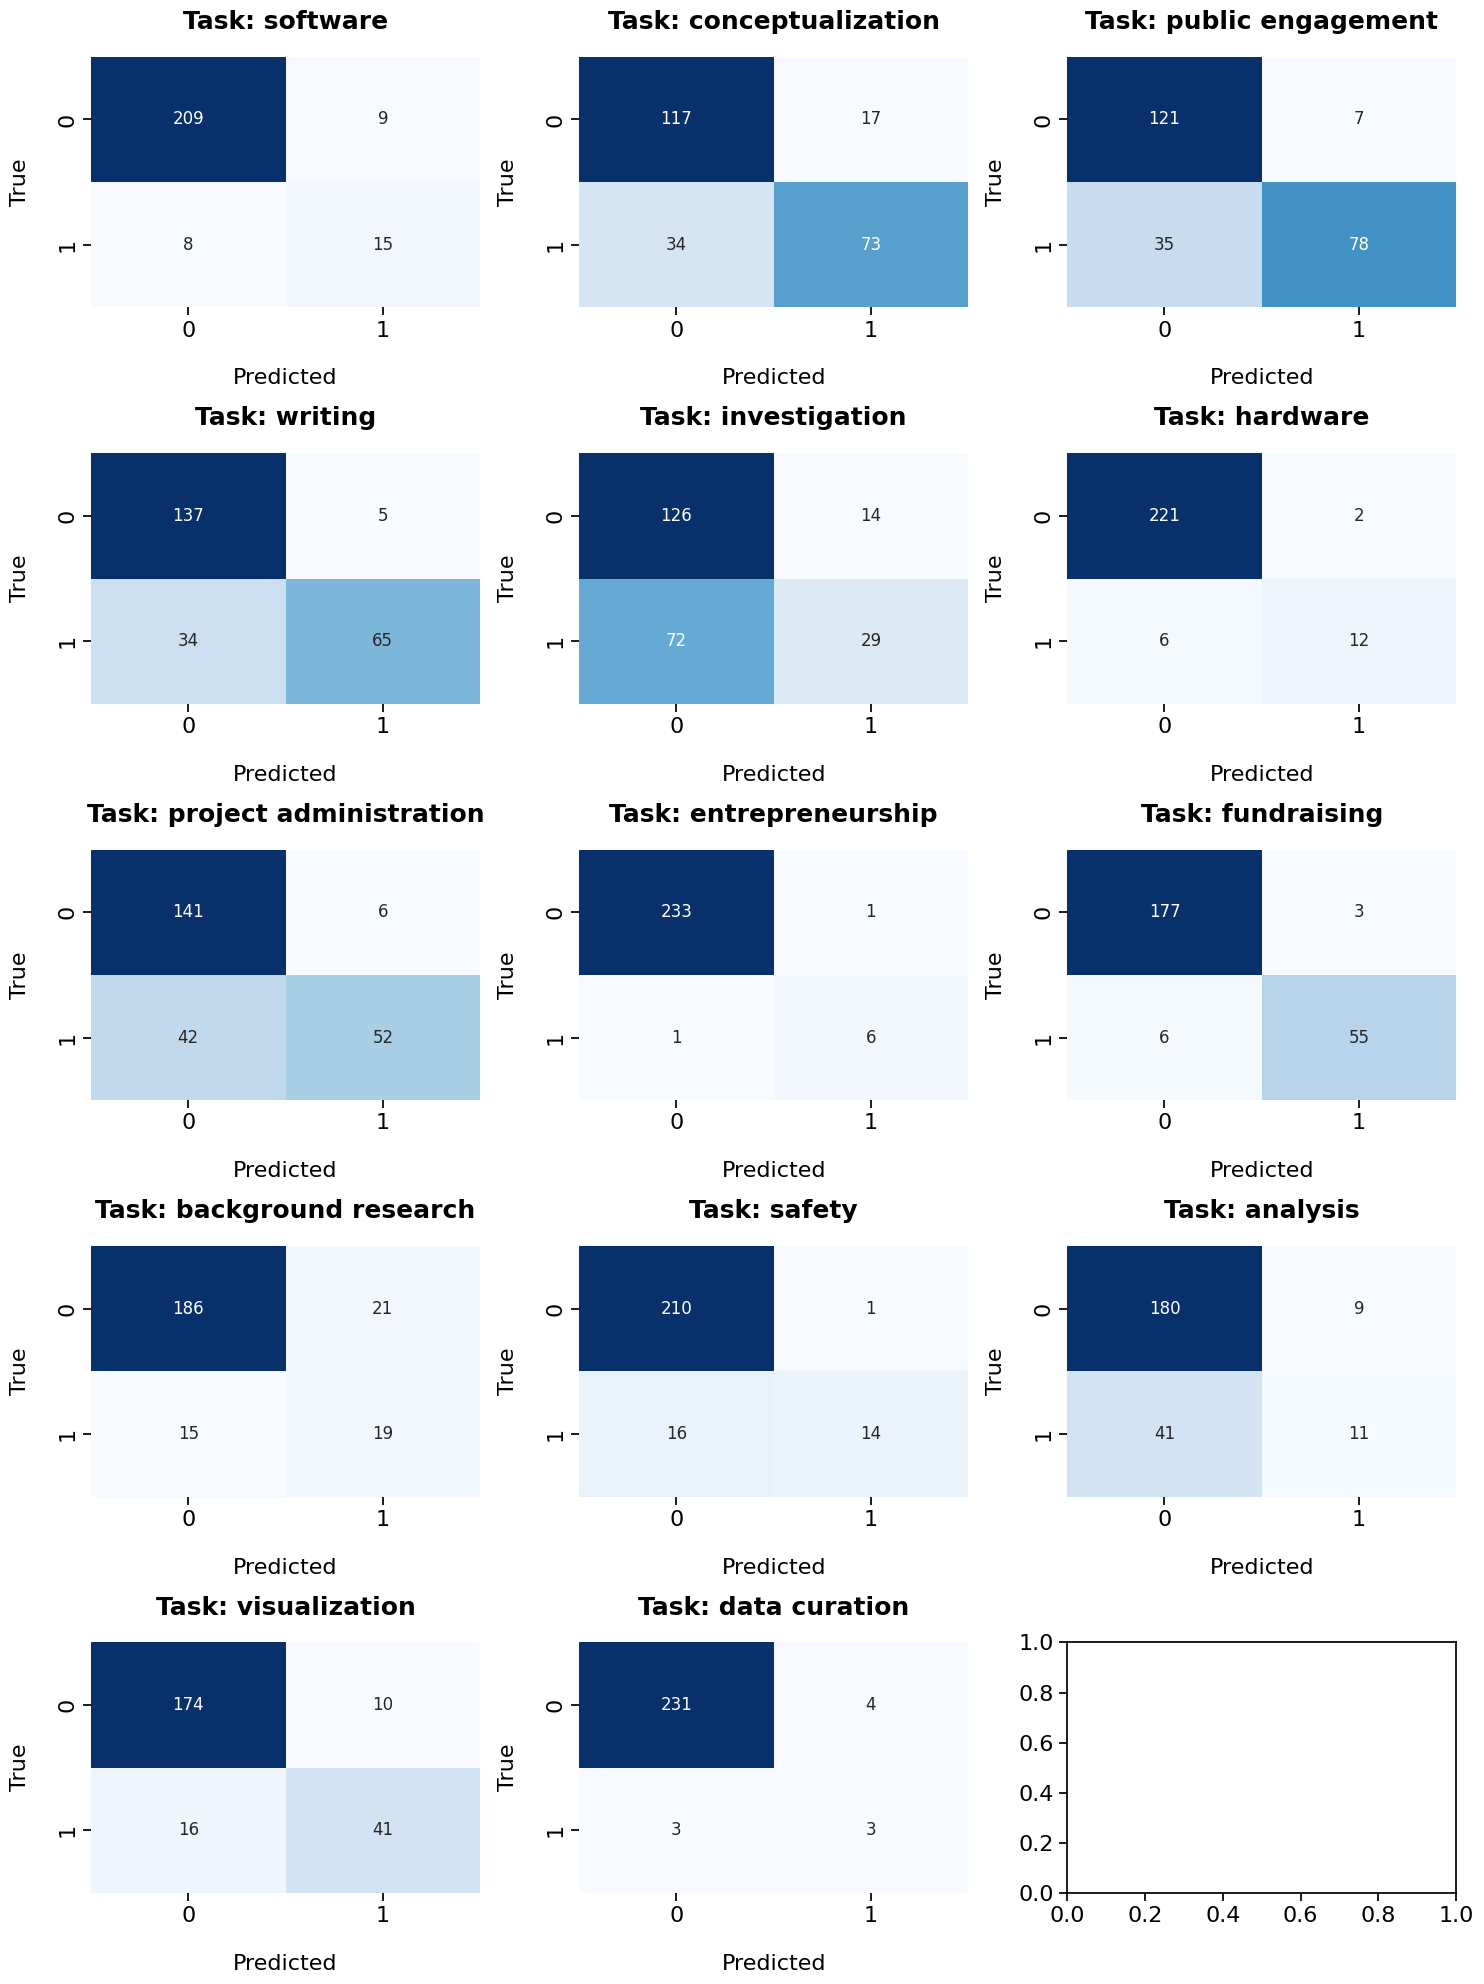

In [50]:
# Confusion Matrices

mcm = multilabel_confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(mcm, labels):
    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
    axes = axes.ravel()
    for i, (matrix, label) in enumerate(zip(mcm, labels)):
        sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
        axes[i].set_title(f"Task: {label}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(mcm, TASK_LABELS)

## 3. LLM Evaluation

In [51]:
llm_df = pd.read_table(LLM_OUTPUTS_PATH, sep="\t")

In [52]:
llm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Team          241 non-null    object
 1   FullName      241 non-null    object
 2   Tasks         241 non-null    object
 3   OutputErrors  12 non-null     object
dtypes: object(4)
memory usage: 7.7+ KB


In [53]:
llm_df["Tasks"] = llm_df["Tasks"].apply(convert_to_list)
llm_df["Labels"] = llm_df["Tasks"].apply(tasks_to_multihot)

In [54]:
# Merge gold and llm dataframes on Team and FullName (because row order may not be the same)
# Inner join - only keep rows present in both dataframes

merged_gold_llm = gold_df.merge(
    llm_df,
    on=["Team", "FullName"],
    suffixes=("_gold", "_llm"),
    how="inner"
)
merged_gold_llm.head()

,Team,FullName,TasksDescription,Tasks_gold,Labels_gold,Tasks_llm,OutputErrors,Labels_llm
0,Aalto-Helsinki,Melissa Hendr�n,She is head of the wet-lab team and involved i...,"[investigation, project administration, fundra...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]","[investigation, fundraising, writing, project ...",NaN,"[0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]"
1,Aalto-Helsinki,Veera Kurki,"She is head of the human practices, the social...","[investigation, project administration, fundra...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]","[public engagement, writing, fundraising, inve...",NaN,"[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]"
2,Aalto-Helsinki,Diogo Dias,is head of the dry-lab. He is involved in the ...,"[analysis, writing, visualization, project adm...","[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0]","[analysis, writing, visualization]",NaN,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0]"
3,Aalto-Helsinki,Amna Gul,is an active member of the wet-lab team. She c...,"[investigation, fundraising, public engagement...","[0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]","[fundraising, public engagement, writing, visu...",NaN,"[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0]"
4,Aalto-Helsinki,Lilith Heiland,is head of the writing team and part of the we...,"[writing, project administration, investigatio...","[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0]","[writing, investigation, fundraising, public e...",NaN,"[0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0]"


In [55]:
print("Gold rows:", len(gold_df))
print("LLM rows:", len(llm_df))
print("Merged rows:", len(merged_gold_llm))

Gold rows: 241
LLM rows: 241
Merged rows: 241


In [56]:
# True and Predicted labels 

y_true = np.array(merged_gold_llm["Labels_gold"].tolist())
y_pred = np.array(merged_gold_llm["Labels_llm"].tolist())

In [57]:
# Classification Report

report = classification_report(
    y_true, 
    y_pred, 
    target_names=TASK_LABELS, 
    zero_division=0
)

print(" ----------------- LLM CLASSIFICATION REPORT ----------------- ")
print(report)

 ----------------- LLM CLASSIFICATION REPORT ----------------- 
                        precision    recall  f1-score   support

              software       0.64      0.91      0.75        23
     conceptualization       0.59      0.98      0.74       107
     public engagement       0.85      0.92      0.89       113
               writing       0.94      0.96      0.95        99
         investigation       0.89      0.91      0.90       101
              hardware       0.64      0.89      0.74        18
project administration       0.70      0.51      0.59        94
      entrepreneurship       0.56      0.71      0.62         7
           fundraising       0.96      0.84      0.89        61
   background research       0.50      0.97      0.66        34
                safety       0.94      0.97      0.95        30
              analysis       0.71      0.69      0.70        52
         visualization       0.73      0.89      0.80        57
         data curation       0.27      

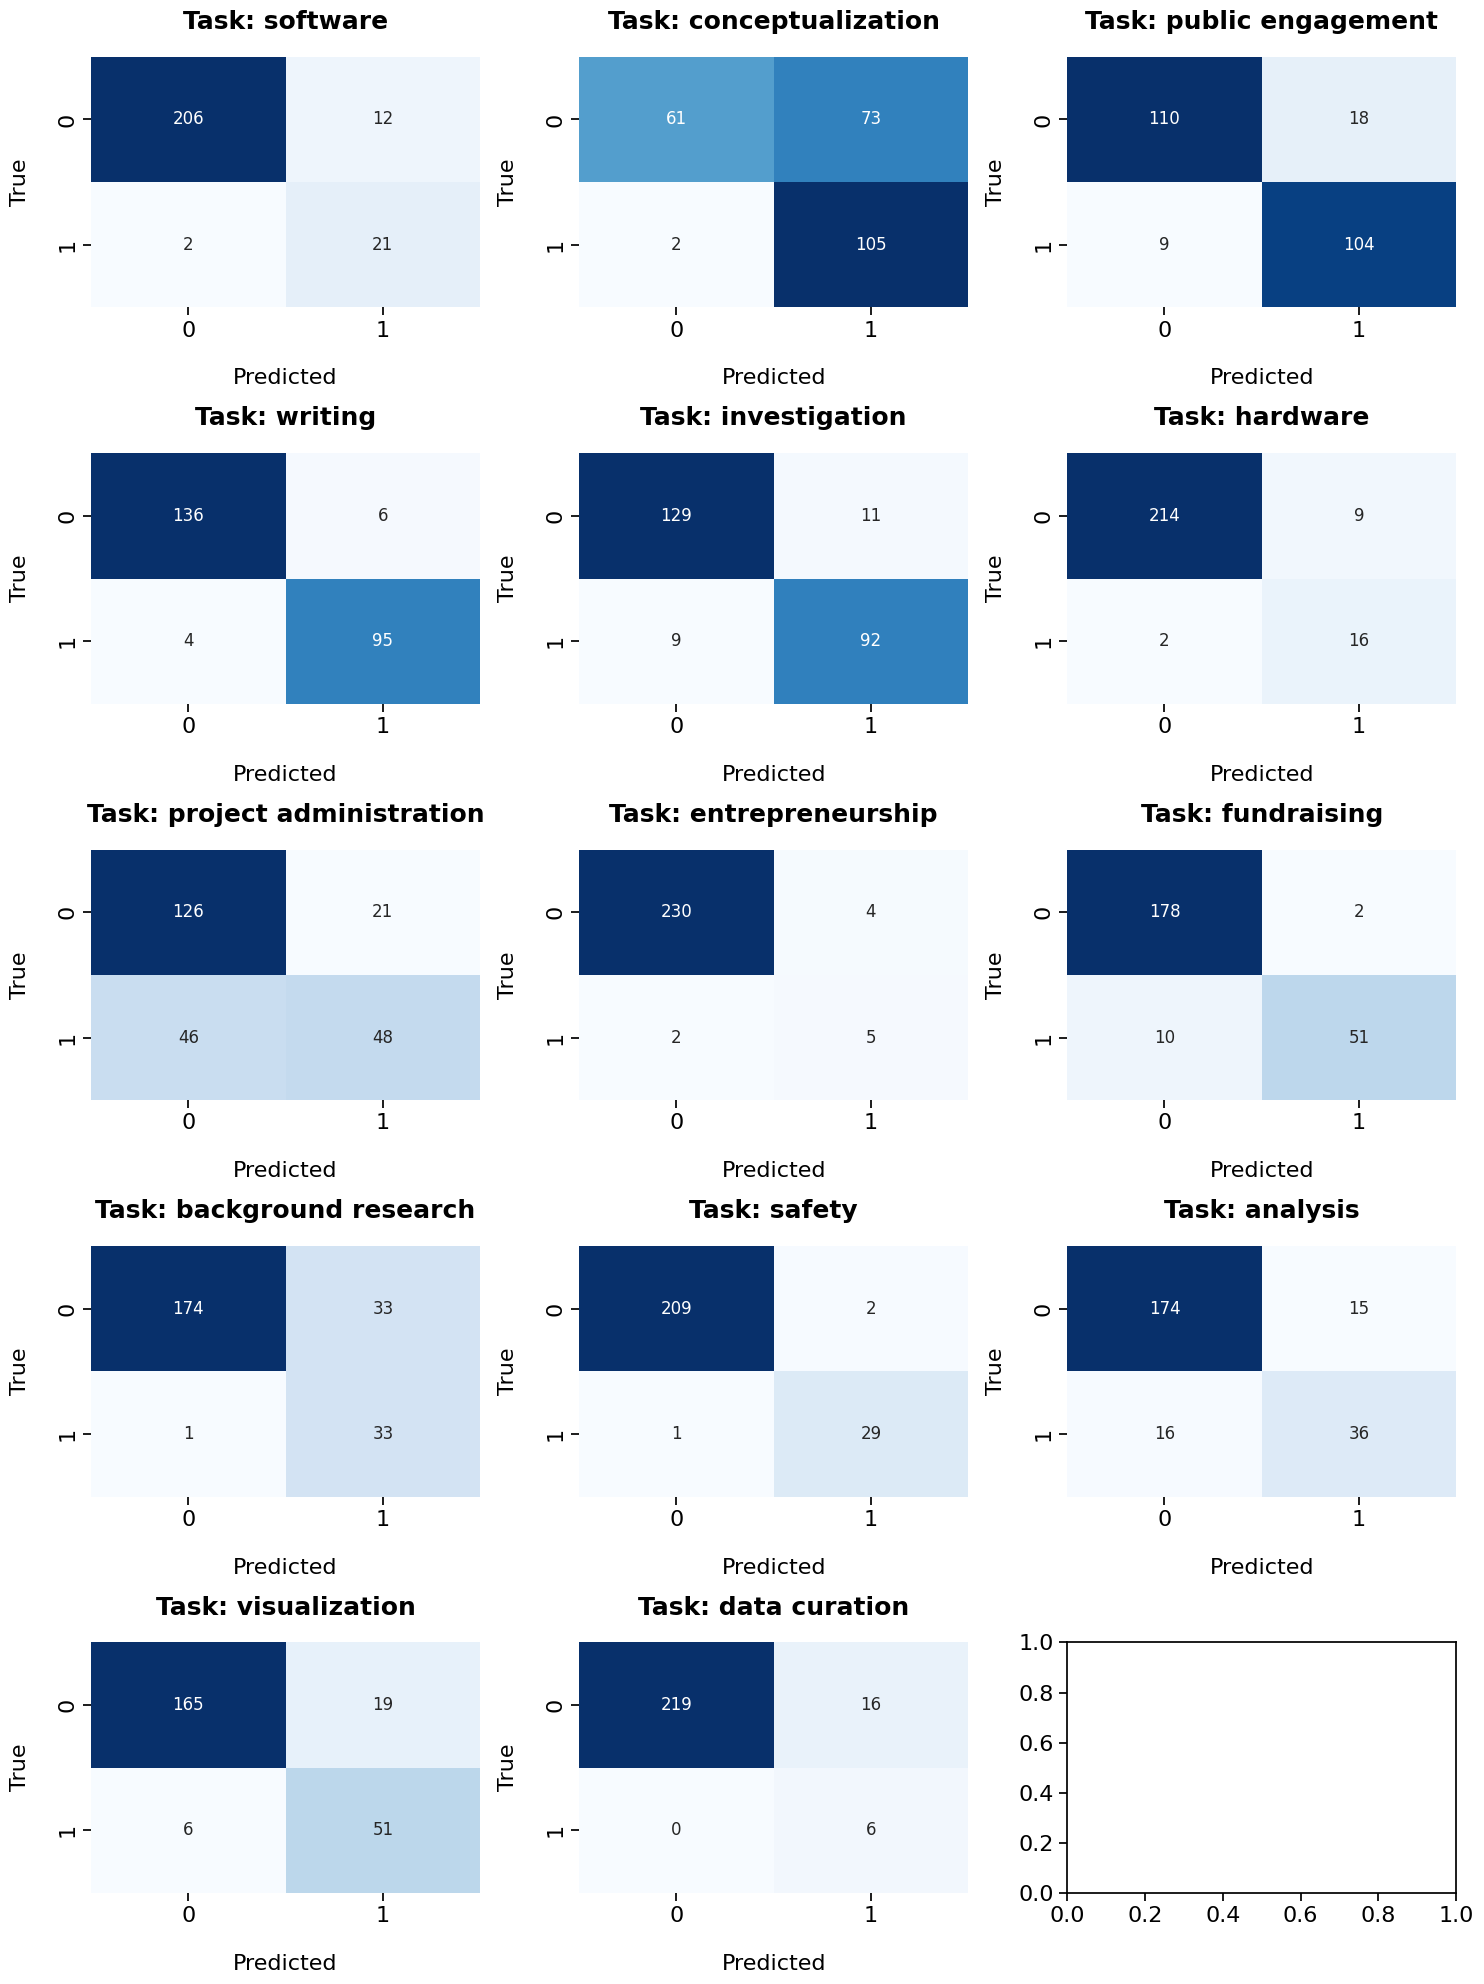

In [58]:
# Confusion Matrices

mcm = multilabel_confusion_matrix(y_true, y_pred)

plot_confusion_matrix(mcm, TASK_LABELS)